# Generalized Hough Transform for an arbitrary template shape

This notebook builds intuition for the **Generalized Hough Transform (GHT)** with a simple arrow template.

The key idea is different from line or circle Hough transforms:

- we do **not** assume an analytic shape like a line or circle
- we start from a **template contour**
- edge points in the new image vote for a likely **reference point** of that template

A useful way to think about the comparison in this notebook is:

- **correlation / template matching** compares image patches directly
- **Generalized Hough** compares **edge geometry and orientation voting**

We will use two OpenCV variants:

- `GeneralizedHoughBallard`: translation only
- `GeneralizedHoughGuil`: translation + rotation + scale search

So this notebook answers a practical question:

> what extra robustness do we gain when we move from direct correlation to a shape-based voting method?


## Method sketch: the R-table and the vote geometry

The Generalized Hough Transform replaces an analytic equation like a line or a circle with a **template-defined contour**.

A compact way to describe it is:

- choose a **reference point** $c$ on the template
- for each template edge point $p$, compute its local edge orientation $\phi(p)$
- store the displacement from the edge point to the reference point

$$
r = c - p
$$

- group these displacement vectors by orientation bin

This orientation-indexed lookup structure is the **R-table**:

$$
R(\phi) = \{r_1, r_2, \dots\}
$$

At detection time, if a scene edge point $x$ has orientation $\phi$, it retrieves the displacement vectors in $R(\phi)$ and votes for candidate reference-point locations:

$$
c = x + r
$$

So the detector is not matching raw pixel patches. It is accumulating **shape votes from edge geometry**.

For pose-aware variants, the same displacement can be rotated and scaled before voting:

$$
c = x + s R_{\theta} r
$$

where $R_{\theta}$ is the 2D rotation matrix, $\theta$ is the angle, and $s$ is the scale.

This is the key difference between the two OpenCV variants used here:

- **Ballard**: mainly translation voting for the template reference point
- **Guil**: voting over **position, rotation, and scale**

That is why Ballard is a good translation-only baseline, while Guil is the more natural method once the shape can rotate or change scale.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from skimage import data

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'


def make_arrow_template(h=80, w=80):
    img = np.zeros((h, w), np.uint8)
    pts = np.array([
        [10, 40], [36, 15], [36, 28], [68, 28], [68, 52], [36, 52], [36, 65]
    ], np.int32)
    cv2.fillPoly(img, [pts], 255)
    return cv2.GaussianBlur(img, (3, 3), 0.6)


def place_template(template, scene_shape=(260, 260), center=(130, 130), angle=0, scale=1.0,
                   intensity=255, occluders=None):
    h, w = template.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    warped = cv2.warpAffine(template, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    canvas = np.zeros(scene_shape, np.uint8)

    x0 = int(round(center[0] - w / 2))
    y0 = int(round(center[1] - h / 2))
    x1, y1 = max(0, x0), max(0, y0)
    x2, y2 = min(scene_shape[1], x0 + w), min(scene_shape[0], y0 + h)

    if x1 < x2 and y1 < y2:
        sx1, sy1 = x1 - x0, y1 - y0
        sx2, sy2 = sx1 + (x2 - x1), sy1 + (y2 - y1)
        patch = (warped[sy1:sy2, sx1:sx2].astype(np.float32) * (intensity / 255.0)).astype(np.uint8)
        canvas[y1:y2, x1:x2] = np.maximum(canvas[y1:y2, x1:x2], patch)

    for occ in occluders or []:
        x, y, ww, hh = occ
        cv2.rectangle(canvas, (x, y), (x + ww, y + hh), 0, -1)

    return cv2.GaussianBlur(canvas, (3, 3), 0.8)


def add_clutter(scene, seed=0):
    out = scene.copy()
    rng = np.random.default_rng(seed)
    for _ in range(10):
        p0 = tuple(rng.integers(0, out.shape[1], 2).tolist())
        p1 = tuple(rng.integers(0, out.shape[1], 2).tolist())
        cv2.line(out, p0, p1, int(rng.integers(60, 120)), 1, cv2.LINE_AA)
    for _ in range(4):
        center = tuple(rng.integers(20, min(out.shape), 2).tolist())
        radius = int(rng.integers(8, 18))
        cv2.circle(out, center, radius, int(rng.integers(70, 120)), 1, cv2.LINE_AA)
    return cv2.GaussianBlur(out, (3, 3), 0.8)


def canny_edges(image, low=30, high=110):
    return cv2.Canny(image, low, high)


def correlation_match(scene, template):
    response = cv2.matchTemplate(scene, template, cv2.TM_CCOEFF_NORMED)
    _, max_value, _, max_loc = cv2.minMaxLoc(response)
    return response, float(max_value), max_loc


def run_ballard(scene, template):
    detector = cv2.createGeneralizedHoughBallard()
    detector.setMinDist(10)
    detector.setLevels(360)
    detector.setDp(2)
    detector.setMaxBufferSize(1000)
    detector.setVotesThreshold(30)
    detector.setCannyLowThresh(30)
    detector.setCannyHighThresh(110)
    detector.setTemplate(template)
    return detector.detect(scene)


def run_guil(scene, template):
    detector = cv2.createGeneralizedHoughGuil()
    detector.setMinDist(10)
    detector.setLevels(360)
    detector.setDp(3)
    detector.setMaxBufferSize(1000)
    detector.setMinAngle(0)
    detector.setMaxAngle(360)
    detector.setAngleStep(1)
    detector.setAngleThresh(1500)
    detector.setMinScale(0.5)
    detector.setMaxScale(2.0)
    detector.setScaleStep(0.05)
    detector.setScaleThresh(50)
    detector.setPosThresh(10)
    detector.setCannyLowThresh(30)
    detector.setCannyHighThresh(110)
    detector.setTemplate(template)
    return detector.detect(scene)


def detections_from_opencv(positions, votes, top_k=3):
    items = []
    if positions is None:
        return items
    pos = positions[0]
    vt = votes[0] if votes is not None else None
    for i in range(min(top_k, len(pos))):
        vote_triplet = tuple(int(v) for v in vt[i]) if vt is not None else None
        items.append({
            'center_x': float(pos[i, 0]),
            'center_y': float(pos[i, 1]),
            'scale': float(pos[i, 2]),
            'angle': float(pos[i, 3]),
            'votes': vote_triplet,
        })
    return items


def rotated_box_points(template_shape, detection):
    h, w = template_shape
    rect = ((detection['center_x'], detection['center_y']), (w * detection['scale'], h * detection['scale']), detection['angle'])
    return cv2.boxPoints(rect)


def draw_detection(ax, template_shape, detection, color='lime', label=None, linewidth=2):
    pts = rotated_box_points(template_shape, detection)
    poly = Polygon(pts, closed=True, fill=False, edgecolor=color, linewidth=linewidth)
    ax.add_patch(poly)
    text = label or f"angle={detection['angle']:.0f}, scale={detection['scale']:.2f}"
    ax.text(detection['center_x'] + 4, detection['center_y'] + 4, text, color=color, fontsize=8)


def draw_corr_box(ax, template_shape, top_left, color='yellow', score=None):
    h, w = template_shape
    rect = Rectangle(top_left, w, h, fill=False, ec=color, lw=2)
    ax.add_patch(rect)
    text = 'correlation' if score is None else f'corr={score:.3f}'
    ax.text(top_left[0] + 4, top_left[1] + 12, text, color=color, fontsize=8)


def print_detections(name, detections):
    print(name)
    if not detections:
        print('  none')
    for i, det in enumerate(detections, start=1):
        print(
            f"  {i:02d}: center=({det['center_x']:.1f}, {det['center_y']:.1f}), "
            f"scale={det['scale']:.2f}, angle={det['angle']:.1f}, votes={det['votes']}"
        )
    print()


arrow_template = make_arrow_template()
translation_scene = place_template(arrow_template, center=(150, 140), angle=0)
rotation_scene = place_template(arrow_template, center=(150, 140), angle=35)
occlusion_scene = place_template(
    arrow_template,
    center=(150, 140),
    angle=35,
    occluders=[(145, 130, 25, 30)],
)
clutter_scene = np.maximum(
    place_template(arrow_template, center=(90, 90), angle=25),
    place_template(arrow_template, center=(185, 175), angle=-20, intensity=220),
)
clutter_scene = add_clutter(clutter_scene, seed=1)

horse = (data.horse().astype(np.uint8) * 255)
ys, xs = np.nonzero(horse)
horse_template = horse[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
horse_template = cv2.resize(horse_template, None, fx=0.4, fy=0.4, interpolation=cv2.INTER_AREA)
real_scene = place_template(horse_template, scene_shape=(260, 320), center=(200, 145), angle=15)


## Template and the edge view used by GHT

We will reuse one **arrow template** across the synthetic experiments.

Generalized Hough does not compare raw pixel patches directly. Instead, it uses the **template contour and edge orientations** to build an internal voting structure.

So before we start, it is useful to see:

- the template itself
- the template edge map that drives the detector


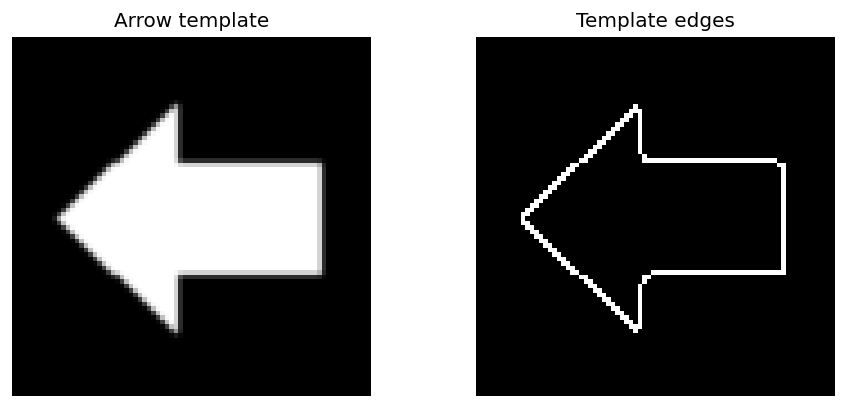

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

axes[0].imshow(arrow_template)
axes[0].set_title('Arrow template')
axes[0].axis('off')

axes[1].imshow(canny_edges(arrow_template))
axes[1].set_title('Template edges')
axes[1].axis('off')

plt.tight_layout()
plt.show()


**Important parameters used below**

- `cv2.matchTemplate(..., cv2.TM_CCOEFF_NORMED)`: normalized correlation. Higher is better, but it still expects the same patch appearance.
- `setVotesThreshold(...)` in `Ballard`: the minimum number of votes required for a center candidate.
- `setMinAngle`, `setMaxAngle`, `setAngleStep` in `Guil`: the angle search range and angular resolution.
- `setMinScale`, `setMaxScale`, `setScaleStep` in `Guil`: the allowed scale range.
- `setPosThresh`, `setAngleThresh`, `setScaleThresh` in `Guil`: how much support is required before a detection is kept.

A good mental model is:

- correlation asks: *which image patch looks most like the template patch?*
- GHT asks: *which location, angle, and scale receive the most contour votes from edge points?*


## Step 0: Correlation only

We begin with **plain correlation** and no Hough voting at all.

This is a useful baseline because it shows both the strength and limitation of direct template matching:

- if the pose matches, correlation is excellent
- if the same shape is rotated, the score drops because the raw patch no longer matches the template orientation


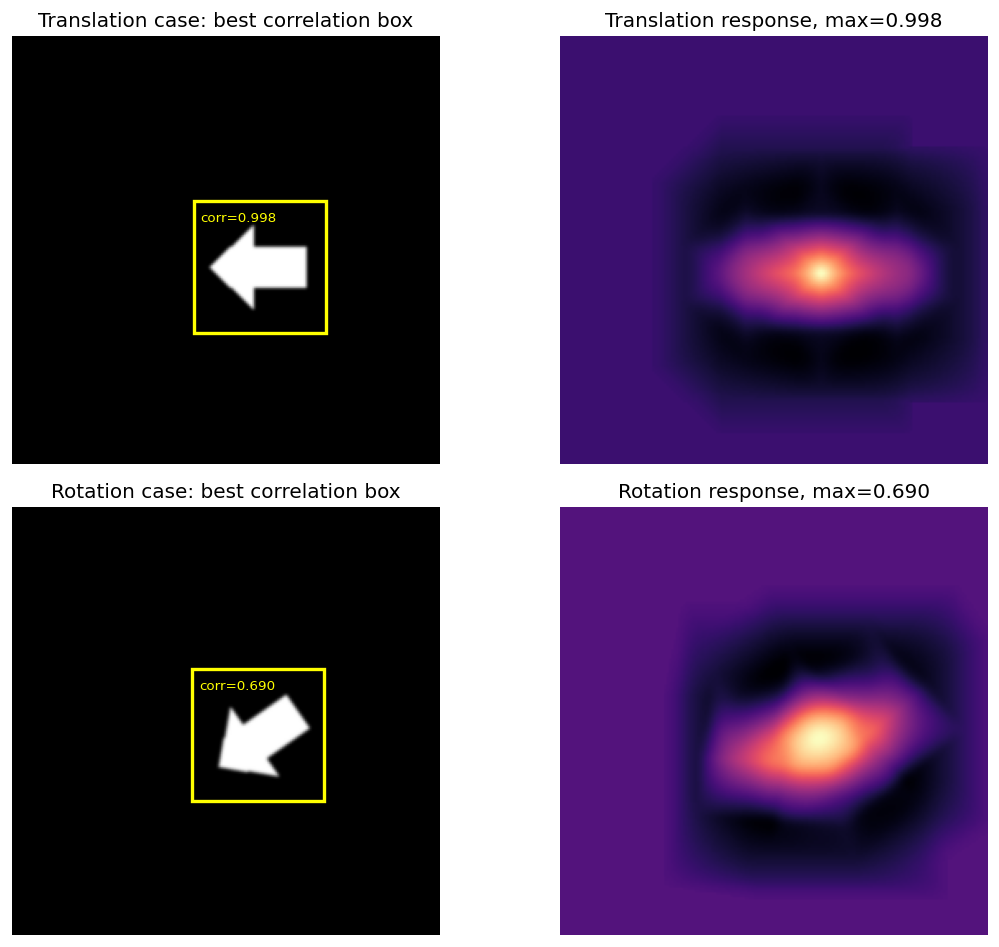

Translation correlation max score: 0.998
Rotation correlation max score:    0.690


In [3]:
corr_t, score_t, top_left_t = correlation_match(translation_scene, arrow_template)
corr_r, score_r, top_left_r = correlation_match(rotation_scene, arrow_template)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(translation_scene)
draw_corr_box(axes[0, 0], arrow_template.shape, top_left_t, score=score_t)
axes[0, 0].set_title('Translation case: best correlation box')
axes[0, 0].axis('off')

axes[0, 1].imshow(corr_t, cmap='magma')
axes[0, 1].set_title(f'Translation response, max={score_t:.3f}')
axes[0, 1].axis('off')

axes[1, 0].imshow(rotation_scene)
draw_corr_box(axes[1, 0], arrow_template.shape, top_left_r, score=score_r)
axes[1, 0].set_title('Rotation case: best correlation box')
axes[1, 0].axis('off')

axes[1, 1].imshow(corr_r, cmap='magma')
axes[1, 1].set_title(f'Rotation response, max={score_r:.3f}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f'Translation correlation max score: {score_t:.3f}')
print(f'Rotation correlation max score:    {score_r:.3f}')


## Experiment 1 ? Translation only: Ballard works well

Now we move to the **Generalized Hough Transform**.

In this first case, the object has the **same orientation and scale** as the template. That is exactly the regime where the simpler **Ballard** variant is appropriate.

Expected behavior:

- correlation works very well
- Ballard also works, because only the center needs to be found


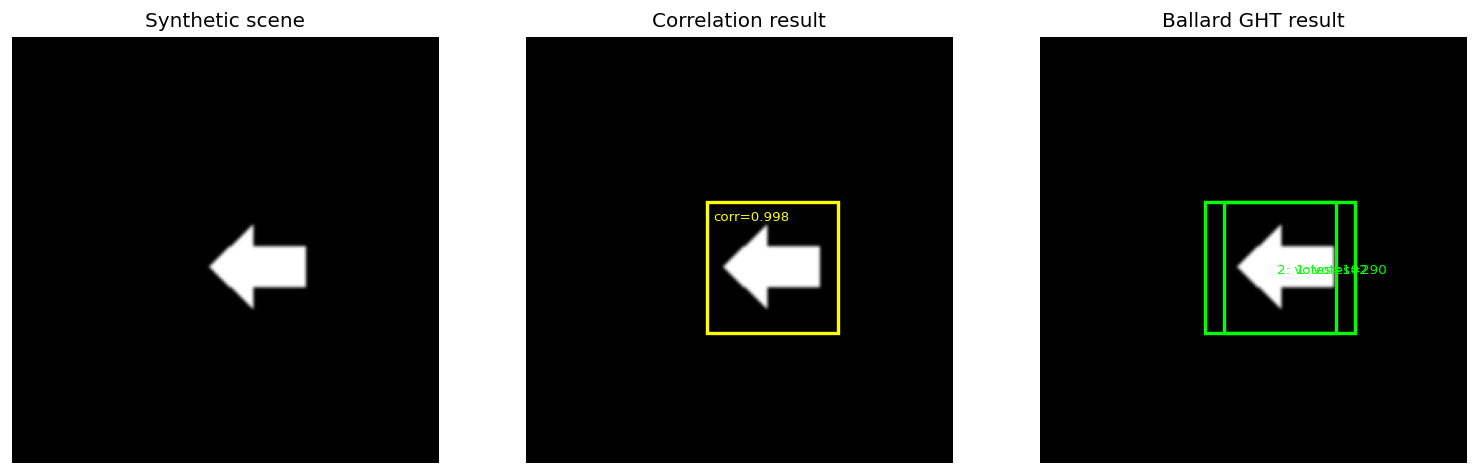

Correlation score: 0.998
Ballard detections:
  01: center=(152.0, 140.0), scale=1.00, angle=0.0, votes=(290, 0, 0)
  02: center=(140.0, 140.0), scale=1.00, angle=0.0, votes=(102, 0, 0)



In [4]:
corr_1, score_1, top_left_1 = correlation_match(translation_scene, arrow_template)
ballard_pos_1, ballard_votes_1 = run_ballard(translation_scene, arrow_template)
ballard_det_1 = detections_from_opencv(ballard_pos_1, ballard_votes_1, top_k=2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(translation_scene)
axes[0].set_title('Synthetic scene')
axes[0].axis('off')

axes[1].imshow(translation_scene)
draw_corr_box(axes[1], arrow_template.shape, top_left_1, score=score_1)
axes[1].set_title('Correlation result')
axes[1].axis('off')

axes[2].imshow(translation_scene)
for i, det in enumerate(ballard_det_1, start=1):
    draw_detection(axes[2], arrow_template.shape, det, color='lime', label=f'{i}: votes={det["votes"][0]}')
axes[2].set_title('Ballard GHT result')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'Correlation score: {score_1:.3f}')
print_detections('Ballard detections:', ballard_det_1)


## Experiment 2 — Rotation: Guil helps, correlation and Ballard do not

Now rotate the same arrow by about \(35^\circ\).

This is the key turning point in the notebook.

Expected behavior:

- correlation degrades because the image patch is no longer aligned with the template
- Ballard fails because it only searches for translation
- Guil succeeds because it votes over **position, angle, and scale**


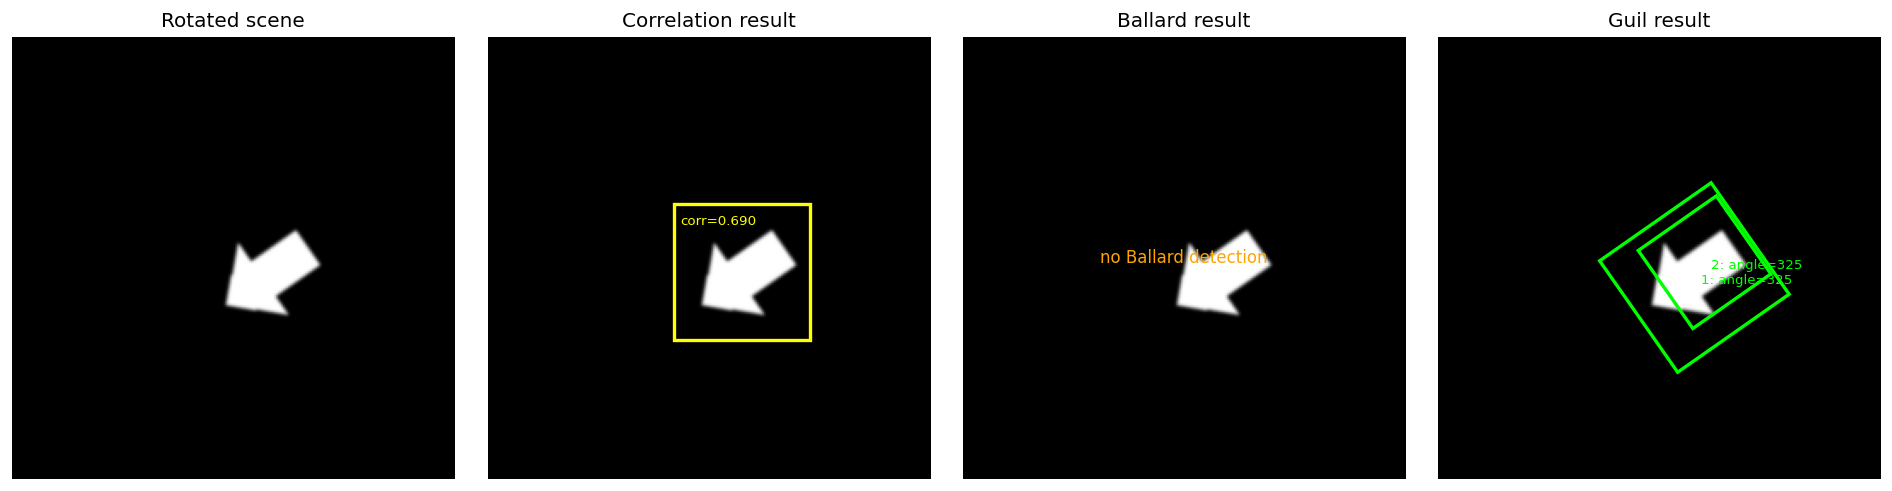

Correlation score: 0.690
Ballard detections:
  none

Guil detections:
  01: center=(150.0, 141.0), scale=1.00, angle=325.0, votes=(1148, 419, 2031)
  02: center=(156.0, 132.0), scale=0.70, angle=325.0, votes=(356, 187, 2031)



In [5]:
corr_2, score_2, top_left_2 = correlation_match(rotation_scene, arrow_template)
ballard_pos_2, ballard_votes_2 = run_ballard(rotation_scene, arrow_template)
guil_pos_2, guil_votes_2 = run_guil(rotation_scene, arrow_template)
ballard_det_2 = detections_from_opencv(ballard_pos_2, ballard_votes_2, top_k=2)
guil_det_2 = detections_from_opencv(guil_pos_2, guil_votes_2, top_k=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(rotation_scene)
axes[0].set_title('Rotated scene')
axes[0].axis('off')

axes[1].imshow(rotation_scene)
draw_corr_box(axes[1], arrow_template.shape, top_left_2, score=score_2)
axes[1].set_title('Correlation result')
axes[1].axis('off')

axes[2].imshow(rotation_scene)
if ballard_det_2:
    for det in ballard_det_2:
        draw_detection(axes[2], arrow_template.shape, det, color='orange')
else:
    axes[2].text(0.5, 0.5, 'no Ballard detection', ha='center', va='center', color='orange', transform=axes[2].transAxes)
axes[2].set_title('Ballard result')
axes[2].axis('off')

axes[3].imshow(rotation_scene)
for i, det in enumerate(guil_det_2, start=1):
    draw_detection(axes[3], arrow_template.shape, det, color='lime', label=f'{i}: angle={det["angle"]:.0f}')
axes[3].set_title('Guil result')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f'Correlation score: {score_2:.3f}')
print_detections('Ballard detections:', ballard_det_2)
print_detections('Guil detections:', guil_det_2)


## Experiment 3 — Partial occlusion

Now remove part of the rotated arrow.

Expected behavior:

- correlation weakens because a visible chunk of the template is missing
- Ballard is still not the right model, because the shape is rotated
- Guil can still succeed if enough contour fragments keep voting for the same pose

This is one of the nice teaching points of Hough-style methods: they can accumulate **partial evidence**.


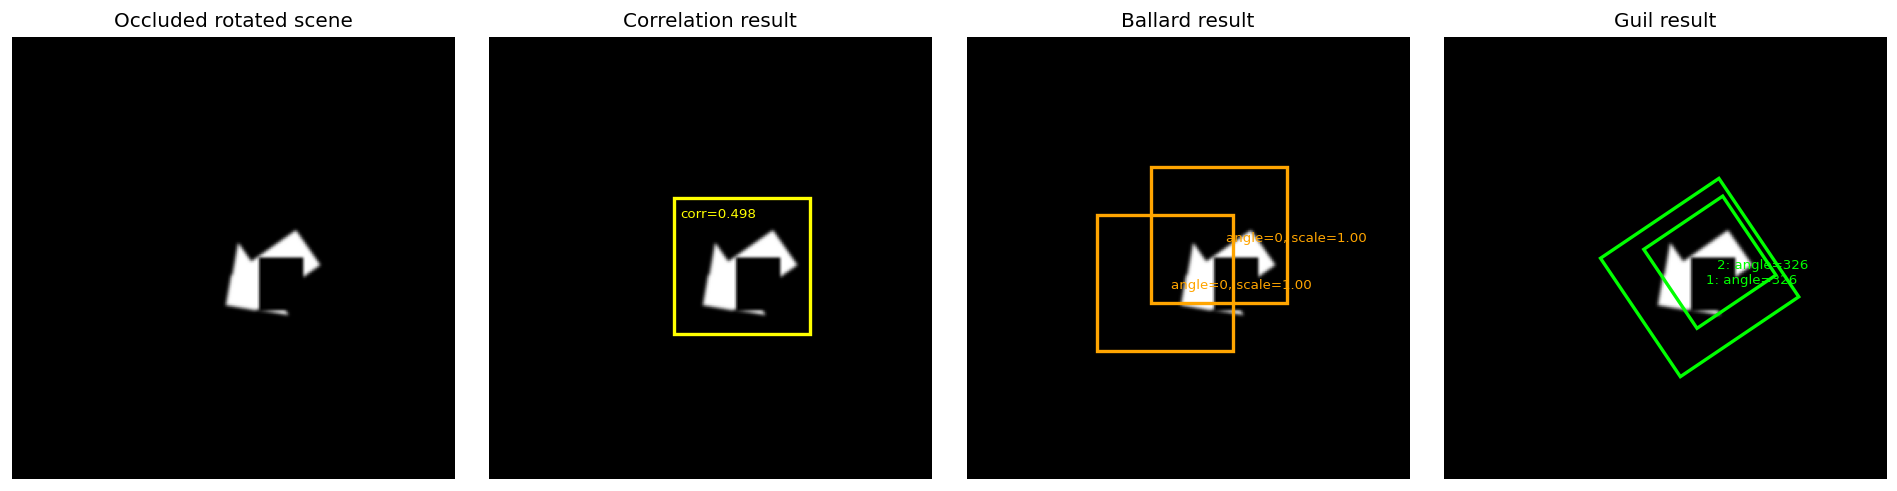

Correlation score: 0.498
Ballard detections:
  01: center=(148.0, 116.0), scale=1.00, angle=0.0, votes=(71, 0, 0)
  02: center=(116.0, 144.0), scale=1.00, angle=0.0, votes=(62, 0, 0)

Guil detections:
  01: center=(150.0, 141.0), scale=1.05, angle=326.0, votes=(298, 71, 2839)
  02: center=(156.0, 132.0), scale=0.70, angle=326.0, votes=(137, 51, 2839)



In [6]:
corr_3, score_3, top_left_3 = correlation_match(occlusion_scene, arrow_template)
ballard_pos_3, ballard_votes_3 = run_ballard(occlusion_scene, arrow_template)
guil_pos_3, guil_votes_3 = run_guil(occlusion_scene, arrow_template)
ballard_det_3 = detections_from_opencv(ballard_pos_3, ballard_votes_3, top_k=2)
guil_det_3 = detections_from_opencv(guil_pos_3, guil_votes_3, top_k=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(occlusion_scene)
axes[0].set_title('Occluded rotated scene')
axes[0].axis('off')

axes[1].imshow(occlusion_scene)
draw_corr_box(axes[1], arrow_template.shape, top_left_3, score=score_3)
axes[1].set_title('Correlation result')
axes[1].axis('off')

axes[2].imshow(occlusion_scene)
if ballard_det_3:
    for det in ballard_det_3:
        draw_detection(axes[2], arrow_template.shape, det, color='orange')
else:
    axes[2].text(0.5, 0.5, 'no Ballard detection', ha='center', va='center', color='orange', transform=axes[2].transAxes)
axes[2].set_title('Ballard result')
axes[2].axis('off')

axes[3].imshow(occlusion_scene)
if guil_det_3:
    for i, det in enumerate(guil_det_3, start=1):
        draw_detection(axes[3], arrow_template.shape, det, color='lime', label=f'{i}: angle={det["angle"]:.0f}')
else:
    axes[3].text(0.5, 0.5, 'no Guil detection', ha='center', va='center', color='lime', transform=axes[3].transAxes)
axes[3].set_title('Guil result')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f'Correlation score: {score_3:.3f}')
print_detections('Ballard detections:', ballard_det_3)
print_detections('Guil detections:', guil_det_3)


## Experiment 4 — Clutter and multiple instances

Now the scene contains:

- two rotated arrows
- many unrelated edge fragments

Expected behavior:

- correlation returns only one best local patch score
- Guil can return **multiple pose candidates** because it is accumulating votes from the contour geometry


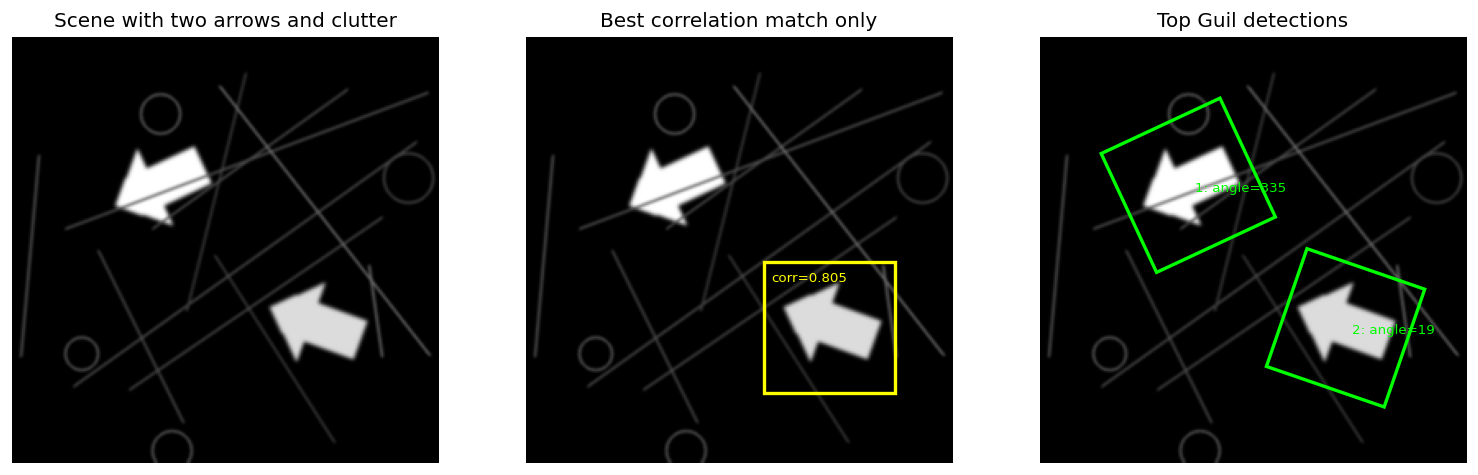

Correlation score: 0.805
Top Guil detections:
  01: center=(90.0, 90.0), scale=1.00, angle=335.0, votes=(1478, 435, 4036)
  02: center=(186.0, 177.0), scale=0.95, angle=19.0, votes=(903, 365, 2554)
  03: center=(72.0, 120.0), scale=1.90, angle=65.0, votes=(557, 193, 2715)
  04: center=(99.0, 81.0), scale=0.60, angle=335.0, votes=(434, 204, 4036)



In [7]:
corr_4, score_4, top_left_4 = correlation_match(clutter_scene, arrow_template)
guil_pos_4, guil_votes_4 = run_guil(clutter_scene, arrow_template)
guil_det_4 = detections_from_opencv(guil_pos_4, guil_votes_4, top_k=4)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(clutter_scene)
axes[0].set_title('Scene with two arrows and clutter')
axes[0].axis('off')

axes[1].imshow(clutter_scene)
draw_corr_box(axes[1], arrow_template.shape, top_left_4, score=score_4)
axes[1].set_title('Best correlation match only')
axes[1].axis('off')

axes[2].imshow(clutter_scene)
for i, det in enumerate(guil_det_4[:2], start=1):
    draw_detection(axes[2], arrow_template.shape, det, color='lime', label=f'{i}: angle={det["angle"]:.0f}')
axes[2].set_title('Top Guil detections')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'Correlation score: {score_4:.3f}')
print_detections('Top Guil detections:', guil_det_4[:4])


## Experiment 5 — Small real-image-style test

For a final sanity check, use a **real silhouette sample** from `skimage.data.horse()`.

This is not a full uncontrolled photograph, but it is a good bridge away from the toy arrow:

- the shape comes from a real image-derived silhouette
- we rotate it in a larger scene
- we compare correlation with Guil again

Expected behavior:

- correlation drops because of the rotation
- Guil still recovers the template pose reasonably well


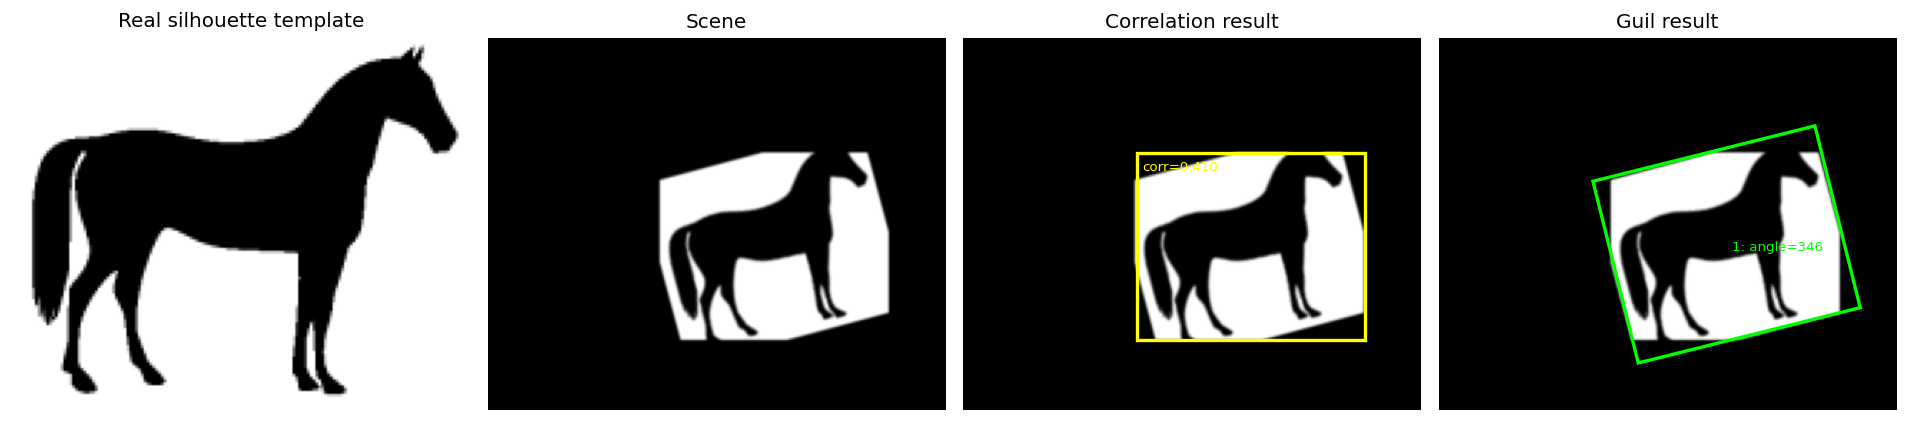

Correlation score: 0.410
Guil detections:
  01: center=(201.0, 144.0), scale=1.00, angle=346.0, votes=(1149, 1360, 25003)
  02: center=(168.0, 228.0), scale=1.95, angle=180.0, votes=(661, 921, 38832)



In [8]:
corr_5, score_5, top_left_5 = correlation_match(real_scene, horse_template)
guil_pos_5, guil_votes_5 = run_guil(real_scene, horse_template)
guil_det_5 = detections_from_opencv(guil_pos_5, guil_votes_5, top_k=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(horse_template)
axes[0].set_title('Real silhouette template')
axes[0].axis('off')

axes[1].imshow(real_scene)
axes[1].set_title('Scene')
axes[1].axis('off')

axes[2].imshow(real_scene)
draw_corr_box(axes[2], horse_template.shape, top_left_5, score=score_5)
axes[2].set_title('Correlation result')
axes[2].axis('off')

axes[3].imshow(real_scene)
for i, det in enumerate(guil_det_5[:1], start=1):
    draw_detection(axes[3], horse_template.shape, det, color='lime', label=f'{i}: angle={det["angle"]:.0f}')
axes[3].set_title('Guil result')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f'Correlation score: {score_5:.3f}')
print_detections('Guil detections:', guil_det_5)


## Extra end case: similar shapes in the same image

This final case is a better stress test than just adding texture.

The scene contains:

- one **true target**: the exact arrow template, but rotated
- one **similar distractor**: an arrow-like shape with a different contour, but easier for raw correlation to like because its pose is closer to the original template

This is the key question:

> if two objects are similar, which method is better at recognizing the **correct template-defined shape**?

Expected behavior:

- fixed-template correlation may prefer the distractor because the image patch is more aligned with the original template appearance
- Generalized Hough with `Guil` can still rank the rotated true target first because it votes from the contour geometry while searching over angle


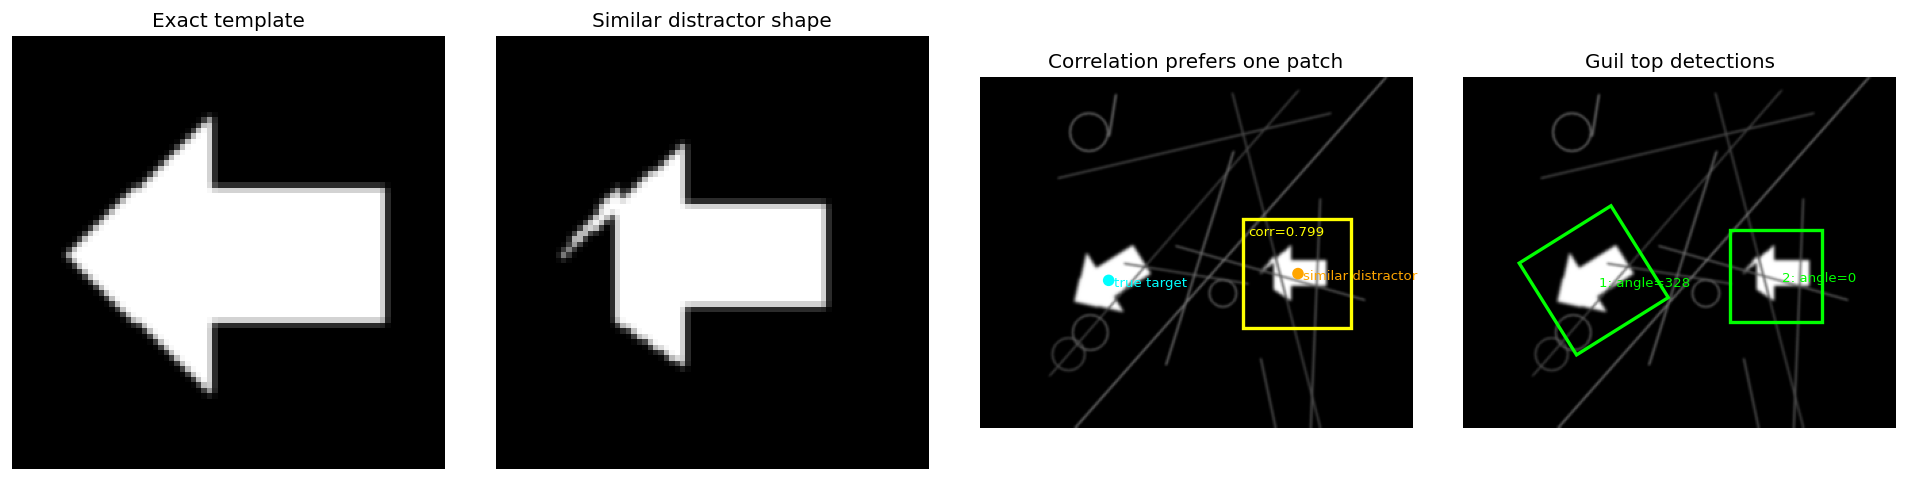

Correlation score: 0.799, top-left box = (194, 105)
Top Guil detections:
  01: center=(96.0, 150.0), scale=1.00, angle=328.0, votes=(878, 240, 2802)
  02: center=(231.0, 147.0), scale=0.85, angle=0.0, votes=(454, 143, 3105)
  03: center=(102.0, 141.0), scale=0.65, angle=328.0, votes=(355, 112, 2802)
  04: center=(243.0, 162.0), scale=0.90, angle=270.0, votes=(308, 60, 3093)



In [11]:
def make_arrow_variant(h=80, w=80):
    img = np.zeros((h, w), np.uint8)
    pts = np.array([
        [12, 40], [34, 20], [34, 31], [60, 31], [60, 49], [34, 49], [34, 60], [22, 52], [22, 28]
    ], np.int32)
    cv2.fillPoly(img, [pts], 255)
    return cv2.GaussianBlur(img, (3, 3), 0.6)


similar_arrow = make_arrow_variant()
complex_scene = np.maximum(
    place_template(arrow_template, scene_shape=(260, 320), center=(95, 150), angle=32, intensity=230),
    place_template(similar_arrow, scene_shape=(260, 320), center=(235, 145), angle=0, intensity=230),
)
complex_scene = add_clutter(complex_scene, seed=3)

corr_6, score_6, top_left_6 = correlation_match(complex_scene, arrow_template)
guil_pos_6, guil_votes_6 = run_guil(complex_scene, arrow_template)
guil_det_6 = detections_from_opencv(guil_pos_6, guil_votes_6, top_k=4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(arrow_template)
axes[0].set_title('Exact template')
axes[0].axis('off')

axes[1].imshow(similar_arrow)
axes[1].set_title('Similar distractor shape')
axes[1].axis('off')

axes[2].imshow(complex_scene)
axes[2].scatter([95, 235], [150, 145], c=['cyan', 'orange'], s=35)
axes[2].text(99, 154, 'true target', color='cyan', fontsize=8)
axes[2].text(239, 149, 'similar distractor', color='orange', fontsize=8)
draw_corr_box(axes[2], arrow_template.shape, top_left_6, score=score_6)
axes[2].set_title('Correlation prefers one patch')
axes[2].axis('off')

axes[3].imshow(complex_scene)
for i, det in enumerate(guil_det_6[:2], start=1):
    draw_detection(axes[3], arrow_template.shape, det, color='lime', label=f'{i}: angle={det["angle"]:.0f}')
axes[3].set_title('Guil top detections')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f'Correlation score: {score_6:.3f}, top-left box = {top_left_6}')
print_detections('Top Guil detections:', guil_det_6[:4])


## Final takeaway

The progression of the notebook is the main lesson:

1. **Correlation** is a direct patch-similarity baseline.
   It is very strong when the template and target have the same pose, but it is sensitive to rotation, occlusion, and clutter.

2. **Ballard generalized Hough** is a shape-voting method for arbitrary templates, but in this form it is mainly a **translation detector**.

3. **Guil generalized Hough** extends the search over **position, angle, and scale**.
   That is why it handles rotated and partially broken contours much better.

So the right summary is:

- classical Hough for lines and circles works with a fixed analytic family
- generalized Hough works with an **arbitrary template-defined contour**
- the gain comes from **edge voting**, not raw pixel correlation

This is why Generalized Hough is a natural next step when the target is a distinctive shape such as an arrow, tool outline, symbol, or silhouette.
